In [4]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

DATA_PATH = "../data/RML2016.10a_dict.pkl"
MODEL_PATH = "../models/teknofest_model_v5_best.keras"
MEAN_PATH = "../scalers/v5_feature_mean.npy"
STD_PATH = "../scalers/v5_feature_std.npy"

print("Çalışma dizini:", os.getcwd())
print("Dosya yolları hazır.")

Çalışma dizini: c:\Users\habib\Desktop\Yapay Zeka Modeli Eğitme\notebooks
Dosya yolları hazır.


In [ ]:
with open(DATA_PATH, "rb") as f:
    Xd = pickle.load(f, encoding="latin1")

snrs = sorted(list(set([k[1] for k in Xd.keys()])))
mods = sorted(list(set([k[0] for k in Xd.keys()])))

print("Modülasyonlar:", mods)
print("SNR seviyeleri:", snrs)

C:\Users\habib\AppData\Local\Temp\ipykernel_23260\3323082481.py:2: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  Xd = pickle.load(f, encoding="latin1")


Modülasyonlar: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR seviyeleri: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [7]:
model_v5 = load_model(MODEL_PATH)

mean_v5 = np.load(MEAN_PATH)
std_v5 = np.load(STD_PATH)

print("V5 modeli yüklendi.")
print("Mean shape:", mean_v5.shape)
print("Std shape:", std_v5.shape)

V5 modeli yüklendi.
Mean shape: (1, 1, 7)
Std shape: (1, 1, 7)


In [8]:
def analyze_iq_fft(
    iq_signal,
    fft_size=256,
    hop_size=128,
    power_threshold_ratio=0.3
):
    peak_bins = []
    bandwidth_bins = []
    total_powers = []

    for start in range(0, len(iq_signal) - fft_size + 1, hop_size):
        window = iq_signal[start:start + fft_size]
        windowed = window * np.hanning(fft_size)

        spectrum = np.fft.fftshift(np.fft.fft(windowed))
        power = np.abs(spectrum) ** 2

        total_powers.append(np.sum(power))

        peak_bin = np.argmax(power)
        peak_bins.append(peak_bin)

        threshold = np.max(power) * power_threshold_ratio
        active_bins = np.where(power >= threshold)[0]

        if len(active_bins) > 0:
            bw = active_bins[-1] - active_bins[0] + 1
        else:
            bw = 0

        bandwidth_bins.append(bw)

    peak_bins = np.array(peak_bins)
    bandwidth_bins = np.array(bandwidth_bins)
    total_powers = np.array(total_powers)

    if len(peak_bins) > 1:
        peak_changes = np.abs(np.diff(peak_bins))
        peak_change_rate = np.mean(peak_changes > 5)
        mean_peak_jump = np.mean(peak_changes)
    else:
        peak_change_rate = 0
        mean_peak_jump = 0

    return {
        "mean_bandwidth_bins": float(np.mean(bandwidth_bins)),
        "max_bandwidth_bins": float(np.max(bandwidth_bins)),
        "peak_change_rate": float(peak_change_rate),
        "mean_peak_jump": float(mean_peak_jump),
        "peak_bins": peak_bins,
        "bandwidth_bins": bandwidth_bins,
        "total_powers": total_powers
    }


def gate_decision(
    fft_features,
    narrow_bw_threshold=25,
    wide_bw_threshold=80,
    hop_rate_threshold=0.35,
    peak_jump_threshold=10
):
    mean_bw = fft_features["mean_bandwidth_bins"]
    max_bw = fft_features["max_bandwidth_bins"]
    peak_change_rate = fft_features["peak_change_rate"]
    mean_peak_jump = fft_features["mean_peak_jump"]

    if peak_change_rate > hop_rate_threshold and mean_peak_jump > peak_jump_threshold:
        return "SPECTROGRAM_MODEL_FHSS_CANDIDATE"

    if mean_bw > wide_bw_threshold or max_bw > wide_bw_threshold:
        return "SPECTROGRAM_MODEL_WIDEBAND_CANDIDATE"

    if mean_bw < narrow_bw_threshold and peak_change_rate < hop_rate_threshold:
        return "V5_IQ_MODEL"

    return "UNKNOWN_OR_LOW_CONFIDENCE"

In [9]:
def create_spectrogram_matrix(
    iq_signal,
    fft_size=256,
    hop_size=64
):
    spec_list = []

    for start in range(0, len(iq_signal) - fft_size + 1, hop_size):
        window = iq_signal[start:start + fft_size]
        windowed = window * np.hanning(fft_size)

        spectrum = np.fft.fftshift(np.fft.fft(windowed))
        power_db = 20 * np.log10(np.abs(spectrum) + 1e-8)

        spec_list.append(power_db)

    return np.array(spec_list)


def plot_spectrogram(spec, title="Waterfall / Spectrogram", save_path=None):
    plt.figure(figsize=(7, 4))
    plt.imshow(
        spec.T,
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )
    plt.xlabel("Zaman Penceresi")
    plt.ylabel("Frekans Bin")
    plt.title(title)
    plt.colorbar(label="Güç (dB)")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

Mod: QPSK
SNR: 10
Mean Bandwidth: 22.736842105263158
Max Bandwidth: 35.0
Peak Change Rate: 0.7222222222222222
Mean Peak Jump: 9.777777777777779
Gate Kararı: UNKNOWN_OR_LOW_CONFIDENCE


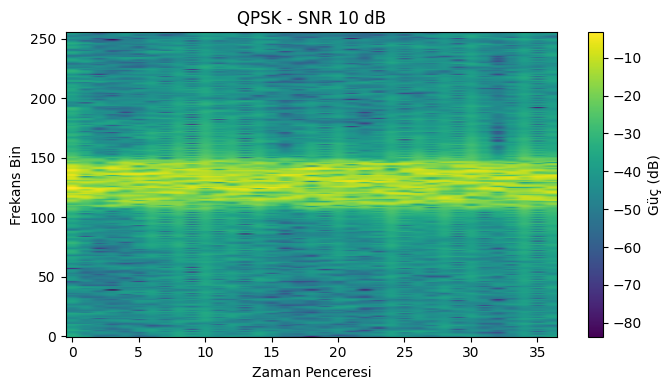

In [ ]:
# Test için bir örnek seçelim
# QPSK modülasyonu ve 10 dB SNR seviyesini seçelim
mod_name = "QPSK"
snr_value = 10

samples = Xd[(mod_name, snr_value)][:20]

iq_signal = samples[:, 0, :].reshape(-1) + 1j * samples[:, 1, :].reshape(-1)

features = analyze_iq_fft(
    iq_signal,
    fft_size=256,
    hop_size=128
)

decision = gate_decision(features)

print("Mod:", mod_name)
print("SNR:", snr_value)
print("Mean Bandwidth:", features["mean_bandwidth_bins"])
print("Max Bandwidth:", features["max_bandwidth_bins"])
print("Peak Change Rate:", features["peak_change_rate"])
print("Mean Peak Jump:", features["mean_peak_jump"])
print("Gate Kararı:", decision)

spec = create_spectrogram_matrix(
    iq_signal,
    fft_size=256,
    hop_size=64
)

plot_spectrogram(
    spec,
    title=f"{mod_name} - SNR {snr_value} dB"
)

In [16]:
# Farklı modülasyonlar ve SNR seviyeleri için testler yapalım
test_mods = ["AM-DSB", "WBFM", "GFSK", "QPSK", "QAM16", "PAM4"]
snr_value = 10

for mod_name in test_mods:
    samples = Xd[(mod_name, snr_value)][:20]
    iq_signal = samples[:, 0, :].reshape(-1) + 1j * samples[:, 1, :].reshape(-1)

    features = analyze_iq_fft(iq_signal)
    decision = gate_decision(features)

    print("\nMod:", mod_name)
    print("Mean BW:", round(features["mean_bandwidth_bins"], 2))
    print("Max BW:", round(features["max_bandwidth_bins"], 2))
    print("Peak Change Rate:", round(features["peak_change_rate"], 2))
    print("Mean Peak Jump:", round(features["mean_peak_jump"], 2))
    print("Decision:", decision)


Mod: AM-DSB
Mean BW: 1.16
Max BW: 2.0
Peak Change Rate: 0.0
Mean Peak Jump: 0.0
Decision: V5_IQ_MODEL

Mod: WBFM
Mean BW: 1.0
Max BW: 1.0
Peak Change Rate: 0.0
Mean Peak Jump: 0.0
Decision: V5_IQ_MODEL

Mod: GFSK
Mean BW: 4.84
Max BW: 7.0
Peak Change Rate: 0.0
Mean Peak Jump: 1.89
Decision: V5_IQ_MODEL

Mod: QPSK
Mean BW: 22.74
Max BW: 35.0
Peak Change Rate: 0.72
Mean Peak Jump: 9.78
Decision: UNKNOWN_OR_LOW_CONFIDENCE

Mod: QAM16
Mean BW: 22.68
Max BW: 34.0
Peak Change Rate: 0.5
Mean Peak Jump: 6.33
Decision: UNKNOWN_OR_LOW_CONFIDENCE

Mod: PAM4
Mean BW: 25.16
Max BW: 35.0
Peak Change Rate: 0.33
Mean Peak Jump: 4.5
Decision: UNKNOWN_OR_LOW_CONFIDENCE


In [12]:
def gate_decision_v2(
    fft_features,
    narrow_bw_threshold=40,
    wide_bw_threshold=90,
    hop_rate_threshold=0.60,
    peak_jump_threshold=18
):
    mean_bw = fft_features["mean_bandwidth_bins"]
    max_bw = fft_features["max_bandwidth_bins"]
    peak_change_rate = fft_features["peak_change_rate"]
    mean_peak_jump = fft_features["mean_peak_jump"]

    # 1. Geniş bant sinyal: OFDM/DSSS adayı olabilir
    if mean_bw > wide_bw_threshold or max_bw > wide_bw_threshold:
        return "SPECTROGRAM_MODEL_WIDEBAND_CANDIDATE"

    # 2. Büyük frekans sıçramaları: FHSS adayı olabilir
    if peak_change_rate > hop_rate_threshold and mean_peak_jump > peak_jump_threshold:
        return "SPECTROGRAM_MODEL_FHSS_CANDIDATE"

    # 3. Dar veya orta bant, büyük hop yoksa V5'e gönder
    if mean_bw < narrow_bw_threshold and mean_peak_jump < peak_jump_threshold:
        return "V5_IQ_MODEL"

    return "UNKNOWN_OR_LOW_CONFIDENCE"

In [22]:
# Farklı modülasyonlar ve SNR seviyeleri için testler yapalım
test_mods = ["AM-DSB", "WBFM", "GFSK", "QPSK", "QAM16", "PAM4"]
snr_value = 10

for mod_name in test_mods:
    samples = Xd[(mod_name, snr_value)][:20]
    iq_signal = samples[:, 0, :].reshape(-1) + 1j * samples[:, 1, :].reshape(-1)

    features = analyze_iq_fft(iq_signal)
    decision = gate_decision(features)

    print("\nMod:", mod_name)
    print("Mean BW:", round(features["mean_bandwidth_bins"], 2))
    print("Max BW:", round(features["max_bandwidth_bins"], 2))
    print("Peak Change Rate:", round(features["peak_change_rate"], 2))
    print("Mean Peak Jump:", round(features["mean_peak_jump"], 2))
    print("Decision:", decision)


Mod: AM-DSB
Mean BW: 1.16
Max BW: 2.0
Peak Change Rate: 0.0
Mean Peak Jump: 0.0
Decision: V5_IQ_MODEL

Mod: WBFM
Mean BW: 1.0
Max BW: 1.0
Peak Change Rate: 0.0
Mean Peak Jump: 0.0
Decision: V5_IQ_MODEL

Mod: GFSK
Mean BW: 4.84
Max BW: 7.0
Peak Change Rate: 0.0
Mean Peak Jump: 1.89
Decision: V5_IQ_MODEL

Mod: QPSK
Mean BW: 22.74
Max BW: 35.0
Peak Change Rate: 0.72
Mean Peak Jump: 9.78
Decision: UNKNOWN_OR_LOW_CONFIDENCE

Mod: QAM16
Mean BW: 22.68
Max BW: 34.0
Peak Change Rate: 0.5
Mean Peak Jump: 6.33
Decision: UNKNOWN_OR_LOW_CONFIDENCE

Mod: PAM4
Mean BW: 25.16
Max BW: 35.0
Peak Change Rate: 0.33
Mean Peak Jump: 4.5
Decision: UNKNOWN_OR_LOW_CONFIDENCE


In [17]:
def generate_simple_fhss_signal(
    num_hops=30,
    samples_per_hop=128,
    freqs=None,
    snr_db=20
):
    if freqs is None:
        freqs = [-0.35, -0.22, -0.10, 0.05, 0.18, 0.32]

    signal_parts = []

    for _ in range(num_hops):
        f = np.random.choice(freqs)
        t = np.arange(samples_per_hop)

        # Kompleks taşıyıcı
        part = np.exp(1j * 2 * np.pi * f * t)

        signal_parts.append(part)

    iq = np.concatenate(signal_parts)

    # AWGN ekle
    signal_power = np.mean(np.abs(iq) ** 2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear

    noise = np.sqrt(noise_power / 2) * (
        np.random.randn(len(iq)) + 1j * np.random.randn(len(iq))
    )

    return iq + noise

FHSS Test
Mean BW: 55.83
Max BW: 175.0
Peak Change Rate: 0.5
Mean Peak Jump: 35.64
Decision: SPECTROGRAM_MODEL_WIDEBAND_CANDIDATE


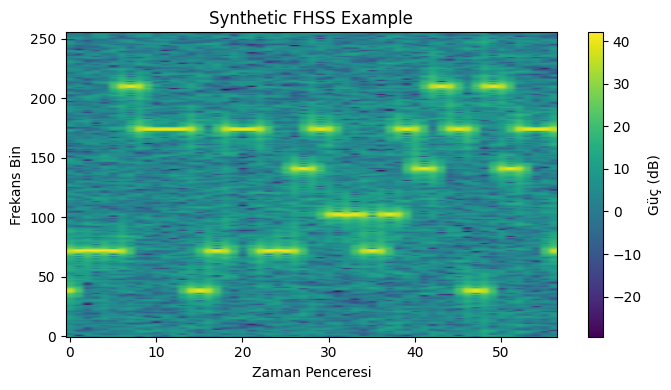

In [18]:
iq_fhss = generate_simple_fhss_signal(
    num_hops=30,
    samples_per_hop=128,
    snr_db=15
)

features_fhss = analyze_iq_fft(
    iq_fhss,
    fft_size=256,
    hop_size=128
)

decision_fhss = gate_decision_v2(features_fhss)

print("FHSS Test")
print("Mean BW:", round(features_fhss["mean_bandwidth_bins"], 2))
print("Max BW:", round(features_fhss["max_bandwidth_bins"], 2))
print("Peak Change Rate:", round(features_fhss["peak_change_rate"], 2))
print("Mean Peak Jump:", round(features_fhss["mean_peak_jump"], 2))
print("Decision:", decision_fhss)

spec_fhss = create_spectrogram_matrix(
    iq_fhss,
    fft_size=256,
    hop_size=64
)

plot_spectrogram(
    spec_fhss,
    title="Synthetic FHSS Example"
)

In [19]:
def gate_decision_v3(
    fft_features,
    narrow_bw_threshold=45,
    wide_bw_threshold=100,
    hop_rate_threshold=0.40,
    peak_jump_threshold=18
):
    mean_bw = fft_features["mean_bandwidth_bins"]
    max_bw = fft_features["max_bandwidth_bins"]
    peak_change_rate = fft_features["peak_change_rate"]
    mean_peak_jump = fft_features["mean_peak_jump"]

    # 1. Önce FHSS kontrolü:
    # Peak belirgin şekilde zıplıyorsa FHSS adayıdır.
    if peak_change_rate >= hop_rate_threshold and mean_peak_jump >= peak_jump_threshold:
        return "SPECTROGRAM_MODEL_FHSS_CANDIDATE"

    # 2. Sonra geniş bant kontrolü:
    # OFDM / DSSS / geniş bant sinyal adayı olabilir.
    if mean_bw >= wide_bw_threshold or max_bw >= wide_bw_threshold:
        return "SPECTROGRAM_MODEL_WIDEBAND_CANDIDATE"

    # 3. Dar/orta bant ve büyük frekans atlaması yoksa V5'e gönder.
    if mean_bw <= narrow_bw_threshold:
        return "V5_IQ_MODEL"

    return "UNKNOWN_OR_LOW_CONFIDENCE"

FHSS Test
Mean BW: 70.14
Max BW: 175.0
Peak Change Rate: 0.43
Mean Peak Jump: 33.29
Decision: SPECTROGRAM_MODEL_FHSS_CANDIDATE


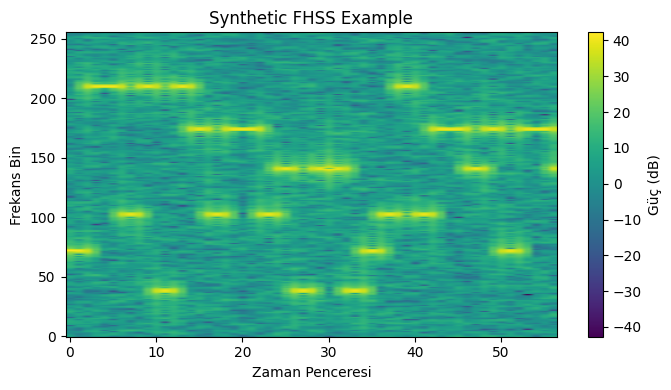

In [21]:
iq_fhss = generate_simple_fhss_signal(
    num_hops=30,
    samples_per_hop=128,
    snr_db=15
)

features_fhss = analyze_iq_fft(
    iq_fhss,
    fft_size=256,
    hop_size=128
)

decision_fhss = gate_decision_v3(features_fhss)

print("FHSS Test")
print("Mean BW:", round(features_fhss["mean_bandwidth_bins"], 2))
print("Max BW:", round(features_fhss["max_bandwidth_bins"], 2))
print("Peak Change Rate:", round(features_fhss["peak_change_rate"], 2))
print("Mean Peak Jump:", round(features_fhss["mean_peak_jump"], 2))
print("Decision:", decision_fhss)

spec_fhss = create_spectrogram_matrix(
    iq_fhss,
    fft_size=256,
    hop_size=64
)

plot_spectrogram(
    spec_fhss,
    title="Synthetic FHSS Example"
)

In [23]:
# ============================================================
# V5 FEATURE EXTRACTION FONKSİYONU
# ------------------------------------------------------------
# Bu fonksiyon RML formatındaki I/Q verisini alır:
# X_iq shape = (N, 2, 128)
#
# Sonra V5 modelinde kullandığımız 7 feature'ı çıkarır:
# I, Q, Amplitude, Phase_sin, Phase_cos, Inst_Freq, Amp_Diff
#
# Çıktı shape = (N, 128, 7)
# ============================================================

def extract_v5_features_from_iq_batch(X_iq):
    # I bileşeni: shape -> (N, 128)
    I = X_iq[:, 0, :]

    # Q bileşeni: shape -> (N, 128)
    Q = X_iq[:, 1, :]

    # Genlik hesabı: sqrt(I^2 + Q^2)
    Amplitude = np.sqrt(I**2 + Q**2)

    # Faz hesabı: atan2(Q, I)
    Phase = np.arctan2(Q, I)

    # Fazı direkt vermek yerine sin/cos ile temsil ediyoruz
    Phase_sin = np.sin(Phase)
    Phase_cos = np.cos(Phase)

    # Fazdaki -pi / +pi sıçramalarını düzeltmek için unwrap
    Phase_unwrapped = np.unwrap(Phase, axis=1)

    # Faz değişimi: anlık frekans benzeri özellik
    Inst_Freq = np.diff(
        Phase_unwrapped,
        axis=1,
        prepend=Phase_unwrapped[:, :1]
    )

    # Genlik değişimi
    Amp_Diff = np.diff(
        Amplitude,
        axis=1,
        prepend=Amplitude[:, :1]
    )

    # Tüm feature'ları birleştiriyoruz
    X_features = np.stack(
        [
            I,
            Q,
            Amplitude,
            Phase_sin,
            Phase_cos,
            Inst_Freq,
            Amp_Diff
        ],
        axis=2
    )

    return X_features

In [24]:
# ============================================================
# V5 MODELİYLE TAHMİN FONKSİYONU
# ------------------------------------------------------------
# Bu fonksiyon tek bir RML I/Q örneği veya batch alır.
#
# Girdi:
# X_iq_128 shape = (N, 2, 128)
#
# İşlem:
# 1. V5 feature'ları çıkarır
# 2. Eğitimde kaydettiğimiz mean/std ile normalize eder
# 3. V5 modeline verir
# 4. En yüksek olasılıklı sınıfı döndürür
# ============================================================

def predict_with_v5(X_iq_128):
    # V5 feature extraction
    X_feat = extract_v5_features_from_iq_batch(X_iq_128)

    # Eğitimde kullanılan mean/std ile normalize ediyoruz
    X_feat_norm = (X_feat - mean_v5) / std_v5

    # Model tahmini
    probs = model_v5.predict(X_feat_norm, verbose=0)

    # En yüksek olasılığın indexini al
    pred_idx = np.argmax(probs, axis=1)

    # Indexleri modülasyon isimlerine çevir
    pred_class = [mods[i] for i in pred_idx]

    return pred_class, probs

In [25]:
# ============================================================
# AKILLI YÖNLENDİRME FONKSİYONU
# ------------------------------------------------------------
# Bu fonksiyon bir I/Q sinyali alır ve karar verir:
#
# 1. Eğer sinyal dar bant / stabil görünüyorsa:
#    -> V5 CNN+LSTM modeline gönderir
#
# 2. Eğer sinyal FHSS gibi frekans atlamalı görünüyorsa:
#    -> Spektrogram tarafına gönderir
#
# 3. Eğer sinyal geniş bant görünüyorsa:
#    -> Spektrogram tarafına gönderir
#
# Not:
# Burada henüz YOLO çalıştırmıyoruz.
# Şimdilik spektrogram çizip kaydediyoruz.
# ============================================================

def smart_router_for_iq(iq_signal, title="Unknown Signal"):
    # 1. FFT tabanlı ucuz analiz yap
    features = analyze_iq_fft(
        iq_signal,
        fft_size=256,
        hop_size=128
    )

    # 2. Gate kararını ver
    decision = gate_decision_v3(features)

    print("========== GATE ANALİZİ ==========")
    print("Sinyal:", title)
    print("Mean BW:", round(features["mean_bandwidth_bins"], 2))
    print("Max BW:", round(features["max_bandwidth_bins"], 2))
    print("Peak Change Rate:", round(features["peak_change_rate"], 2))
    print("Mean Peak Jump:", round(features["mean_peak_jump"], 2))
    print("Gate Kararı:", decision)

    # 3. Eğer V5 modeline gidecekse
    if decision == "V5_IQ_MODEL":
        print("\nYönlendirme: V5 CNN+LSTM modeline gönderiliyor.")

        # V5 modeli 128 örneklik parçalar bekliyor.
        # Bu yüzden uzun iq_signal'ı 128'lik parçalara böleceğiz.
        sample_len = 128
        num_chunks = len(iq_signal) // sample_len

        # Eğer yeterli veri yoksa hata vermesin
        if num_chunks == 0:
            print("Hata: V5 için yeterli uzunlukta I/Q sinyal yok.")
            return decision, None

        # Fazla kalan kısmı atıyoruz
        iq_cut = iq_signal[:num_chunks * sample_len]

        # 128'lik parçalara bölüyoruz
        chunks = iq_cut.reshape(num_chunks, sample_len)

        # RML formatına çeviriyoruz: (N, 2, 128)
        X_iq = np.zeros((num_chunks, 2, sample_len), dtype=np.float32)
        X_iq[:, 0, :] = np.real(chunks)
        X_iq[:, 1, :] = np.imag(chunks)

        # V5 tahminini al
        pred_classes, probs = predict_with_v5(X_iq)

        # En çok çıkan sınıfı final karar olarak alıyoruz
        final_pred = max(set(pred_classes), key=pred_classes.count)

        print("Parça sayısı:", num_chunks)
        print("Parça tahminleri:", pred_classes[:10], "...")
        print("Final V5 Tahmini:", final_pred)

        return decision, final_pred

    # 4. Eğer spektrogram tarafına gidecekse
    elif decision in [
        "SPECTROGRAM_MODEL_FHSS_CANDIDATE",
        "SPECTROGRAM_MODEL_WIDEBAND_CANDIDATE"
    ]:
        print("\nYönlendirme: Spektrogram / YOLO tarafına gönderilecek.")

        # Spektrogram matrisi oluştur
        spec = create_spectrogram_matrix(
            iq_signal,
            fft_size=256,
            hop_size=64
        )

        # Spektrogramı çiz
        plot_spectrogram(
            spec,
            title=f"{title} - {decision}"
        )

        return decision, "SPECTROGRAM_BRANCH"

    # 5. Belirsiz durum
    else:
        print("\nYönlendirme: Belirsiz / düşük güven.")
        return decision, None

In [26]:
# ============================================================
# TEST 1: RML2016'DAN NORMAL BİR MODÜLASYON
# ------------------------------------------------------------
# Bu testte QPSK örneklerini arka arkaya ekliyoruz.
# Gate'in bunu V5 modeline yönlendirmesini bekliyoruz.
# ============================================================

mod_name = "QPSK"
snr_value = 10

# RML2016'dan 20 adet QPSK örneği alıyoruz
samples = Xd[(mod_name, snr_value)][:20]

# RML formatı: (20, 2, 128)
# Bunu uzun kompleks I/Q akışına çeviriyoruz
iq_signal = samples[:, 0, :].reshape(-1) + 1j * samples[:, 1, :].reshape(-1)

# Akıllı yönlendirme fonksiyonunu çalıştır
decision, result = smart_router_for_iq(
    iq_signal,
    title=f"{mod_name} SNR {snr_value} dB"
)

print("\nSonuç:", decision, result)

========== GATE ANALİZİ ==========
Sinyal: QPSK SNR 10 dB
Mean BW: 22.74
Max BW: 35.0
Peak Change Rate: 0.72
Mean Peak Jump: 9.78
Gate Kararı: V5_IQ_MODEL

Yönlendirme: V5 CNN+LSTM modeline gönderiliyor.
Parça sayısı: 20
Parça tahminleri: ['QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK', 'QPSK'] ...
Final V5 Tahmini: QPSK

Sonuç: V5_IQ_MODEL QPSK


========== GATE ANALİZİ ==========
Sinyal: Synthetic FHSS
Mean BW: 70.1
Max BW: 111.0
Peak Change Rate: 0.61
Mean Peak Jump: 49.75
Gate Kararı: SPECTROGRAM_MODEL_FHSS_CANDIDATE

Yönlendirme: Spektrogram / YOLO tarafına gönderilecek.


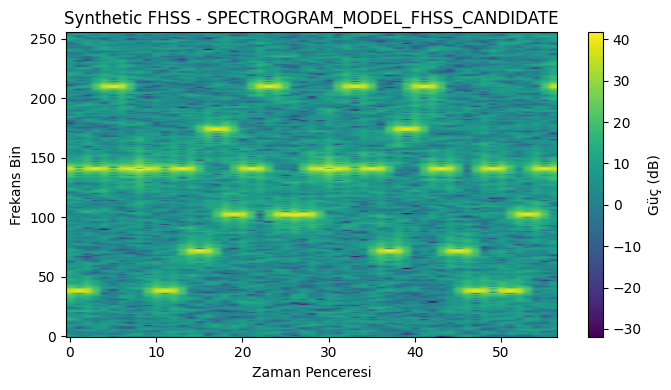


Sonuç: SPECTROGRAM_MODEL_FHSS_CANDIDATE SPECTROGRAM_BRANCH


In [27]:
# ============================================================
# TEST 2: SENTETİK FHSS SİNYALİ
# ------------------------------------------------------------
# Bu testte yapay frekans atlamalı sinyal üretiyoruz.
# Gate'in bunu V5'e değil, spektrogram tarafına göndermesini bekliyoruz.
# ============================================================

iq_fhss = generate_simple_fhss_signal(
    num_hops=30,
    samples_per_hop=128,
    snr_db=15
)

decision, result = smart_router_for_iq(
    iq_fhss,
    title="Synthetic FHSS"
)

print("\nSonuç:", decision, result)

In [ ]:
# ============================================================
# TEST 3: RML2016 MODÜLASYONLARI ÜZERİNDE AKILLI ROUTER TESTİ
# ------------------------------------------------------------
# Amaç:
# RML2016 veri setindeki klasik modülasyonların gate tarafından
# V5 modeline yönlendirilip yönlendirilmediğini görmek.
#
# Beklenti:
# Bu sınıfların çoğu V5_IQ_MODEL kararı almalı.
# ============================================================

test_mods = [
    "8PSK",
    "AM-DSB",
    "AM-SSB",
    "BPSK",
    "CPFSK",
    "GFSK",
    "PAM4",
    "QAM16",
    "QAM64",
    "QPSK",
    "WBFM"
]

snr_value = 10

router_results = []

for mod_name in test_mods:
    # Her modülasyondan 20 örnek alıyoruz
    samples = Xd[(mod_name, snr_value)][:20]

    # RML formatındaki örnekleri uzun kompleks I/Q akışına çeviriyoruz
    iq_signal = samples[:, 0, :].reshape(-1) + 1j * samples[:, 1, :].reshape(-1)

    # FFT analizini yapıyoruz
    features = analyze_iq_fft(
        iq_signal,
        fft_size=256,
        hop_size=128
    )

    # Gate kararını alıyoruz
    decision = gate_decision_v4(features)

    # Eğer gate V5 diyorsa V5 tahmini de alıyoruz
    if decision == "V5_IQ_MODEL":
        sample_len = 128
        num_chunks = len(iq_signal) // sample_len
        iq_cut = iq_signal[:num_chunks * sample_len]
        chunks = iq_cut.reshape(num_chunks, sample_len)

        X_iq = np.zeros((num_chunks, 2, sample_len), dtype=np.float32)
        X_iq[:, 0, :] = np.real(chunks)
        X_iq[:, 1, :] = np.imag(chunks)

        pred_classes, probs = predict_with_v5(X_iq)
        final_pred = max(set(pred_classes), key=pred_classes.count)
    else:
        final_pred = "SPECTROGRAM_BRANCH"

    router_results.append({
        "Gerçek Sınıf": mod_name,
        "SNR": snr_value,
        "Mean BW": round(features["mean_bandwidth_bins"], 2),
        "Max BW": round(features["max_bandwidth_bins"], 2),
        "Peak Change Rate": round(features["peak_change_rate"], 2),
        "Mean Peak Jump": round(features["mean_peak_jump"], 2),
        "Gate Kararı": decision,
        "Final Tahmin": final_pred
    })

# Sonuçları tablo olarak gösteriyoruz
import pandas as pd

router_df = pd.DataFrame(router_results)
router_df

,Gerçek Sınıf,SNR,Mean BW,Max BW,Peak Change Rate,Mean Peak Jump,Gate Kararı,Final Tahmin
0,8PSK,10,24.95,35.0,0.78,10.39,V5_IQ_MODEL,8PSK
1,AM-DSB,10,1.16,2.0,0.00,0.00,V5_IQ_MODEL,AM-DSB
2,AM-SSB,10,233.95,256.0,1.00,87.89,SPECTROGRAM_MODEL_FHSS_CANDIDATE,SPECTROGRAM_BRANCH
3,BPSK,10,27.32,37.0,0.33,4.22,V5_IQ_MODEL,BPSK
4,CPFSK,10,13.58,28.0,0.22,3.78,V5_IQ_MODEL,CPFSK
5,GFSK,10,4.84,7.0,0.00,1.89,V5_IQ_MODEL,GFSK
6,PAM4,10,25.16,35.0,0.33,4.50,V5_IQ_MODEL,PAM4
7,QAM16,10,22.68,34.0,0.50,6.33,V5_IQ_MODEL,QAM16
8,QAM64,10,21.74,32.0,0.61,8.00,V5_IQ_MODEL,QAM64
9,QPSK,10,22.74,35.0,0.72,9.78,V5_IQ_MODEL,QPSK


In [29]:
# ============================================================
# GATE DECISION V4
# ------------------------------------------------------------
# Bu versiyon önceki gate_decision_v3'ün daha güvenli halidir.
#
# Problem:
# AM-SSB gibi bazı sinyallerde FFT peak noktası çok oynayabiliyor.
# Eski gate bunu yanlışlıkla FHSS sanabiliyordu.
#
# Çözüm:
# FHSS kararı vermek için:
# 1. Peak zaman içinde belirgin sıçramalı
# 2. Ortalama bant genişliği çok aşırı geniş olmamalı
#
# Çünkü FHSS genelde zaman içinde farklı frekanslara atlar,
# ama her anda belirli bir kanalda yoğunlaşır.
# ============================================================

def gate_decision_v4(
    fft_features,
    fhss_bw_max=90,          # FHSS için ortalama bant genişliği üst sınırı
    hop_rate_threshold=0.40, # Peak değişim oranı eşiği
    peak_jump_threshold=18,  # Ortalama peak sıçrama eşiği
    enable_wideband_branch=False,
    wide_bw_threshold=160
):
    mean_bw = fft_features["mean_bandwidth_bins"]
    max_bw = fft_features["max_bandwidth_bins"]
    peak_change_rate = fft_features["peak_change_rate"]
    mean_peak_jump = fft_features["mean_peak_jump"]

    # --------------------------------------------------------
    # 1. FHSS adayı kontrolü
    # --------------------------------------------------------
    # FHSS için peak zıplamalı ama sinyal ortalama olarak
    # AM-SSB gibi aşırı geniş görünmemeli.
    if (
        peak_change_rate >= hop_rate_threshold
        and mean_peak_jump >= peak_jump_threshold
        and mean_bw <= fhss_bw_max
    ):
        return "SPECTROGRAM_MODEL_FHSS_CANDIDATE"

    # --------------------------------------------------------
    # 2. Geniş bant aday kontrolü
    # --------------------------------------------------------
    # Şimdilik bunu kapalı tutuyoruz.
    # Çünkü elimizde henüz OFDM/DSSS modeli yok.
    # Açarsak AM-SSB gibi bazı bilinen sınıfları yanlışlıkla
    # spektrogram tarafına atabilir.
    if enable_wideband_branch:
        if mean_bw >= wide_bw_threshold or max_bw >= 220:
            return "SPECTROGRAM_MODEL_WIDEBAND_CANDIDATE"

    # --------------------------------------------------------
    # 3. Diğer her şeyi V5 modeline gönder
    # --------------------------------------------------------
    # Mevcut 11 RML sınıfı V5 tarafından biliniyor.
    # Bu yüzden güvenli varsayım: FHSS değilse V5'e gönder.
    return "V5_IQ_MODEL"

In [30]:
# ============================================================
# TEST 3: RML2016 MODÜLASYONLARI ÜZERİNDE AKILLI ROUTER TESTİ
# ------------------------------------------------------------
# Amaç:
# RML2016 veri setindeki klasik modülasyonların gate tarafından
# V5 modeline yönlendirilip yönlendirilmediğini görmek.
#
# Beklenti:
# Bu sınıfların çoğu V5_IQ_MODEL kararı almalı.
# ============================================================

test_mods = [
    "8PSK",
    "AM-DSB",
    "AM-SSB",
    "BPSK",
    "CPFSK",
    "GFSK",
    "PAM4",
    "QAM16",
    "QAM64",
    "QPSK",
    "WBFM"
]

snr_value = 10

router_results = []

for mod_name in test_mods:
    # Her modülasyondan 20 örnek alıyoruz
    samples = Xd[(mod_name, snr_value)][:20]

    # RML formatındaki örnekleri uzun kompleks I/Q akışına çeviriyoruz
    iq_signal = samples[:, 0, :].reshape(-1) + 1j * samples[:, 1, :].reshape(-1)

    # FFT analizini yapıyoruz
    features = analyze_iq_fft(
        iq_signal,
        fft_size=256,
        hop_size=128
    )

    # Gate kararını alıyoruz
    decision = gate_decision_v4(features)

    # Eğer gate V5 diyorsa V5 tahmini de alıyoruz
    if decision == "V5_IQ_MODEL":
        sample_len = 128
        num_chunks = len(iq_signal) // sample_len
        iq_cut = iq_signal[:num_chunks * sample_len]
        chunks = iq_cut.reshape(num_chunks, sample_len)

        X_iq = np.zeros((num_chunks, 2, sample_len), dtype=np.float32)
        X_iq[:, 0, :] = np.real(chunks)
        X_iq[:, 1, :] = np.imag(chunks)

        pred_classes, probs = predict_with_v5(X_iq)
        final_pred = max(set(pred_classes), key=pred_classes.count)
    else:
        final_pred = "SPECTROGRAM_BRANCH"

    router_results.append({
        "Gerçek Sınıf": mod_name,
        "SNR": snr_value,
        "Mean BW": round(features["mean_bandwidth_bins"], 2),
        "Max BW": round(features["max_bandwidth_bins"], 2),
        "Peak Change Rate": round(features["peak_change_rate"], 2),
        "Mean Peak Jump": round(features["mean_peak_jump"], 2),
        "Gate Kararı": decision,
        "Final Tahmin": final_pred
    })

# Sonuçları tablo olarak gösteriyoruz
import pandas as pd

router_df = pd.DataFrame(router_results)
router_df

,Gerçek Sınıf,SNR,Mean BW,Max BW,Peak Change Rate,Mean Peak Jump,Gate Kararı,Final Tahmin
0,8PSK,10,24.95,35.0,0.78,10.39,V5_IQ_MODEL,8PSK
1,AM-DSB,10,1.16,2.0,0.00,0.00,V5_IQ_MODEL,AM-DSB
2,AM-SSB,10,233.95,256.0,1.00,87.89,V5_IQ_MODEL,AM-SSB
3,BPSK,10,27.32,37.0,0.33,4.22,V5_IQ_MODEL,BPSK
4,CPFSK,10,13.58,28.0,0.22,3.78,V5_IQ_MODEL,CPFSK
5,GFSK,10,4.84,7.0,0.00,1.89,V5_IQ_MODEL,GFSK
6,PAM4,10,25.16,35.0,0.33,4.50,V5_IQ_MODEL,PAM4
7,QAM16,10,22.68,34.0,0.50,6.33,V5_IQ_MODEL,QAM16
8,QAM64,10,21.74,32.0,0.61,8.00,V5_IQ_MODEL,QAM64
9,QPSK,10,22.74,35.0,0.72,9.78,V5_IQ_MODEL,QPSK


In [31]:
# ============================================================
# ROUTER TEST SONUÇLARINI KAYDETME
# ------------------------------------------------------------
# Bu hücre router_df tablosunu CSV olarak kaydeder.
# Böylece rapora/sunuma koymak için elimizde sonuç dosyası olur.
# ============================================================

import os

# outputs/reports klasörü yoksa oluştur
os.makedirs("../outputs/reports", exist_ok=True)

# Router sonuçlarını kaydet
router_df.to_csv("../outputs/reports/router_gate_v4_rml_test.csv", index=False)

print("Kaydedildi: ../outputs/reports/router_gate_v4_rml_test.csv")

Kaydedildi: ../outputs/reports/router_gate_v4_rml_test.csv


In [32]:
# ============================================================
# SENTETİK FHSS TEST SONUCUNU KAYDETME
# ------------------------------------------------------------
# Bu hücre sentetik FHSS için gate kararını CSV olarak kaydeder.
# ============================================================

fhss_result = {
    "Signal": "Synthetic FHSS",
    "Mean BW": round(features_fhss["mean_bandwidth_bins"], 2),
    "Max BW": round(features_fhss["max_bandwidth_bins"], 2),
    "Peak Change Rate": round(features_fhss["peak_change_rate"], 2),
    "Mean Peak Jump": round(features_fhss["mean_peak_jump"], 2),
    "Gate Kararı": decision_fhss
}

fhss_df = pd.DataFrame([fhss_result])

fhss_df.to_csv("../outputs/reports/router_gate_v4_fhss_test.csv", index=False)

fhss_df

,Signal,Mean BW,Max BW,Peak Change Rate,Mean Peak Jump,Gate Kararı
0,Synthetic FHSS,70.14,175.0,0.43,33.29,SPECTROGRAM_MODEL_FHSS_CANDIDATE


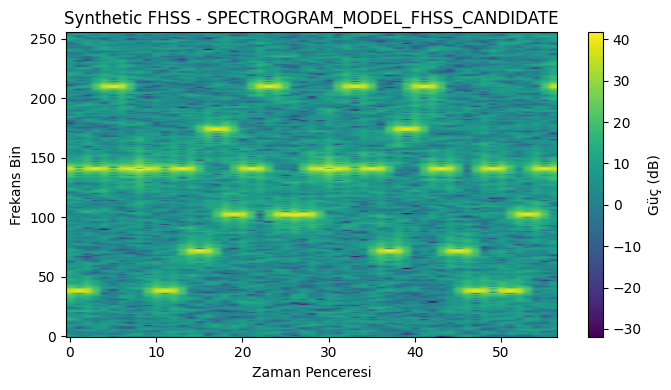

Kaydedildi: ../outputs/figures/synthetic_fhss_spectrogram.png


In [33]:
# ============================================================
# SENTETİK FHSS SPEKTROGRAM GÖRSELİNİ KAYDETME
# ------------------------------------------------------------
# Bu hücre FHSS spektrogramını png olarak kaydeder.
# ============================================================

os.makedirs("../outputs/figures", exist_ok=True)

spec_fhss = create_spectrogram_matrix(
    iq_fhss,
    fft_size=256,
    hop_size=64
)

plot_spectrogram(
    spec_fhss,
    title=f"Synthetic FHSS - {decision_fhss}",
    save_path="../outputs/figures/synthetic_fhss_spectrogram.png"
)

print("Kaydedildi: ../outputs/figures/synthetic_fhss_spectrogram.png")